# Actividad 3.2 - Carga y Exploración de Datos
## Dataset: precios históricos del oro

### Cargar el dataset

In [73]:
import pandas as pd

df = pd.read_csv("../Actividad3.2/finalgolddata.csv")
print("Dataset cargado")
print(df.shape)

Dataset cargado
(6399, 6)


### Primeras 10 filas

In [74]:
df.head(10)


,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0
5,07-09-00,274.000000,274.000000,274.000000,274.000000,125
6,08-09-00,273.299988,273.299988,273.299988,273.299988,0
7,11-09-00,273.100006,273.100006,273.100006,273.100006,0
8,12-09-00,272.899994,272.899994,272.899994,272.899994,0
9,13-09-00,272.799988,272.799988,272.799988,272.799988,0


### Información del dataset

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6399 non-null   str    
 1   Open    6399 non-null   float64
 2   High    6399 non-null   float64
 3   Low     6399 non-null   float64
 4   Close   6399 non-null   float64
 5   Volume  6399 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 300.1 KB


### Tipos de datos

In [76]:
print(df.dtypes)

Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


### Valores nulos

In [77]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


### Estadísticas básicas

In [78]:
df.describe()

,Open,High,Low,Close,Volume
count,6399.000000,6399.000000,6399.000000,6399.000000,6399.000000
mean,1274.892437,1281.728724,1267.908032,1274.961009,4282.543522
std,782.868133,788.800733,777.090788,783.122438,24051.637361
min,255.000000,256.100006,255.000000,255.100006,0.000000
25%,651.000000,653.649994,649.149994,651.699982,23.000000
50%,1251.599976,1256.199951,1244.800049,1251.099976,117.000000
75%,1694.700012,1706.099976,1683.250000,1695.649964,450.500000
max,5415.700195,5586.200195,5334.899902,5377.299805,386334.000000


## Contenido de Actividad3.3\n

# Actividad 3.3 - Limpieza de Datos
## Dataset: precios históricos del oro

### Cargar el dataset

In [79]:
import pandas as pd

df = pd.read_csv("../Actividad3.2/finalgolddata.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,30-08-00,273.899994,273.899994,273.899994,273.899994,0
1,31-08-00,274.799988,278.299988,274.799988,278.299988,0
2,01-09-00,277.000000,277.000000,277.000000,277.000000,0
3,05-09-00,275.799988,275.799988,275.799988,275.799988,2
4,06-09-00,274.200012,274.200012,274.200012,274.200012,0


### Renombrar columnas a minúsculas

In [80]:
df.columns = df.columns.str.lower()
print(df.columns.tolist())

['date', 'open', 'high', 'low', 'close', 'volume']


### Convertir la columna Date a tipo fecha

In [81]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%y")
print(df["date"].dtype)
df["date"].head(3)

datetime64[us]


0   2000-08-30
1   2000-08-31
2   2000-09-01
Name: date, dtype: datetime64[us]

### Revisar y manejar valores nulos

In [82]:
print("Nulos antes:")
print(df.isnull().sum())

# Si hay nulos los rellenamos con el valor de antes para no perder datos
df["open"] = df["open"].ffill()
df["high"] = df["high"].ffill()
df["low"] = df["low"].ffill()
df["close"] = df["close"].ffill()
df["volume"] = df["volume"].fillna(0)

print("\nNulos después:")
print(df.isnull().sum())

Nulos antes:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Nulos después:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


### Eliminar duplicados

In [83]:
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicados después:", df.duplicated().sum())

Duplicados: 0
Duplicados después: 0


### Crear nuevas columnas

In [84]:
# Sacar el año y el mes de la fecha
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Cuánto varió el precio en el día (entre el más alto y el más bajo)
df["rango_diario"] = df["high"] - df["low"]

# Si el precio subió o bajó comparando apertura y cierre
df["cambio"] = df["close"] - df["open"]

df.head()

,date,open,high,low,close,volume,year,month,rango_diario,cambio
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,2000,8,0.0,0.0
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,2000,8,3.5,3.5
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,2000,9,0.0,0.0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,2000,9,0.0,0.0
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,2000,9,0.0,0.0


### Estado final del dataset

In [85]:
print(df.shape)
print(df.dtypes)
df.head()

(6399, 10)
date            datetime64[us]
open                   float64
high                   float64
low                    float64
close                  float64
volume                   int64
year                     int32
month                    int32
rango_diario           float64
cambio                 float64
dtype: object


,date,open,high,low,close,volume,year,month,rango_diario,cambio
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,2000,8,0.0,0.0
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,2000,8,3.5,3.5
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,2000,9,0.0,0.0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,2000,9,0.0,0.0
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,2000,9,0.0,0.0


### Conclusiones

- Le cambié los nombres a las columnas para que fueran en minúsculas y así no tener que estar poniendo mayúsculas cada vez.
- La columna de fecha estaba guardada como texto y la convertí a formato fecha.
- No había datos nulos ni repetidos en este dataset.
- Agregué columnas nuevas: el año, el mes, cuánto varió el precio en el día y si subió o bajó entre apertura y cierre.

## Contenido de Actividad3.4\n

# Actividad 3.4 - Visualización Exploratoria
## Dataset: precios históricos del oro (ya limpiado)

### 1. Histograma del precio de cierre

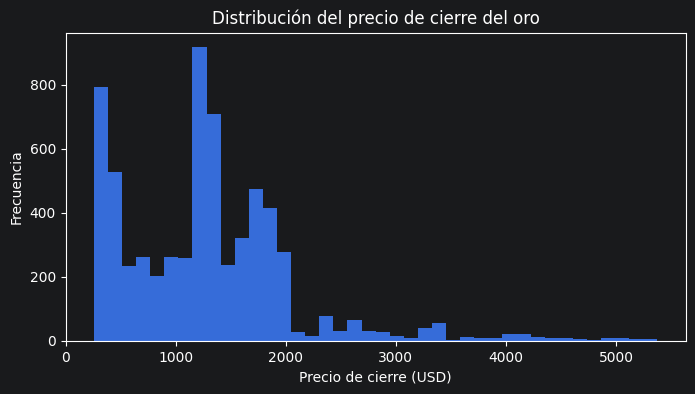

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.hist(df["close"], bins=40)
plt.title("Distribución del precio de cierre del oro")
plt.xlabel("Precio de cierre (USD)")
plt.ylabel("Frecuencia")
plt.savefig("HistogramaPrecio.png")
plt.show()

__Interpretación:__ La mayoría de los precios están entre 200 y 2000 dólares más o menos. Se ve que hay muchos más días con precios bajos que con precios muy altos. Y es porque el oro era más barato antes y con el tiempo fue subiendo.

### 2. Gráfico de barras: precio promedio por año

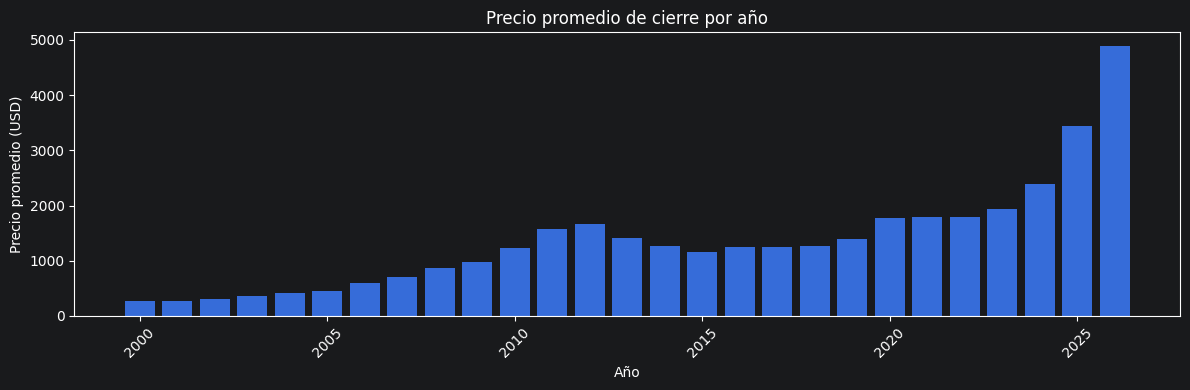

In [87]:
promedio_año = df.groupby("year")["close"].mean()

plt.figure(figsize=(12, 4))
plt.bar(promedio_año.index, promedio_año.values)
plt.title("Precio promedio de cierre por año")
plt.xlabel("Año")
plt.ylabel("Precio promedio (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("PrecioPromDeCiere.png")
plt.show()

__Interpretación:__ Se ve bien claro que el precio fue subiendo cada año. En el año 2000 era muy barato y en los más recientes está muy caro.

### 3. Diagrama de dispersión: precio de apertura vs precio de cierre

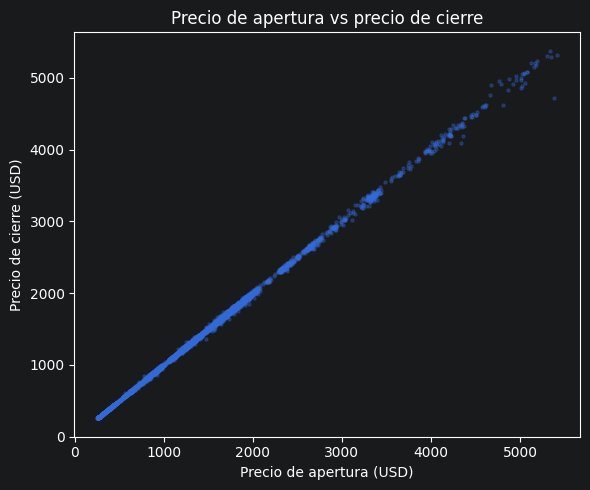

In [88]:
plt.figure(figsize=(6, 5))
plt.scatter(df["open"], df["close"], alpha=0.3, s=5)
plt.title("Precio de apertura vs precio de cierre")
plt.xlabel("Precio de apertura (USD)")
plt.ylabel("Precio de cierre (USD)")
plt.tight_layout()
plt.savefig("PrecioDeApertura_VS_PrecioDeCierre.png")
plt.show()

__Interpretación:__ Los puntos forman casi una línea diagonal, eso significa que el precio de apertura y el de cierre son casi iguales cada día. Tiene sentido porque en un solo día el precio no va a cambiar muchísimo.

## 4. Mapa de calor de correlaciones

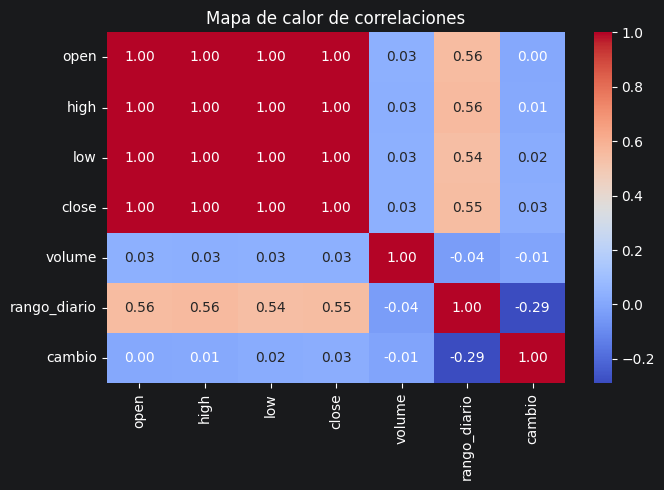

In [89]:
columnas = ["open", "high", "low", "close", "volume", "rango_diario", "cambio"]
correlaciones = df[columnas].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.savefig("heatmap_correlaciones.png")
plt.show()

**Interpretación:** Los precios open, high, low y close tienen números muy cercanos a 1, lo que quiere decir que están muy relacionados entre sí. El volumen tiene números más chicos, eso significa que no tiene mucha relación con el precio.